In [1]:
import pandas as pd
from soil_fertility.components.data_ingestion import DataIngestion
from soil_fertility.components.data_transformation.data_transformation_part2 import DataTransformationTwo
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [2]:
import yaml
with open("config.yaml", 'r') as file:
    config = yaml.safe_load(file)
    second_dataset = config['paths']['second_dataset']

In [3]:
obj = DataIngestion()

part,train_path,test_path= obj.init_ingestion(
    second_dataset
)

In [4]:
print("part : ",part)
print("train_path : ",Path(train_path))
print("test_path : ",Path(test_path))

part :  1
train_path :  D:\2026 projects\DataMining-project\artifacts\raw\1\train.csv
test_path :  D:\2026 projects\DataMining-project\artifacts\raw\1\test.csv


# Transformation

In [5]:
transformation_obj=DataTransformationTwo()
part,preprocessor,second_dataset=transformation_obj.transform(second_dataset)

In [6]:
df=pd.read_csv(second_dataset)

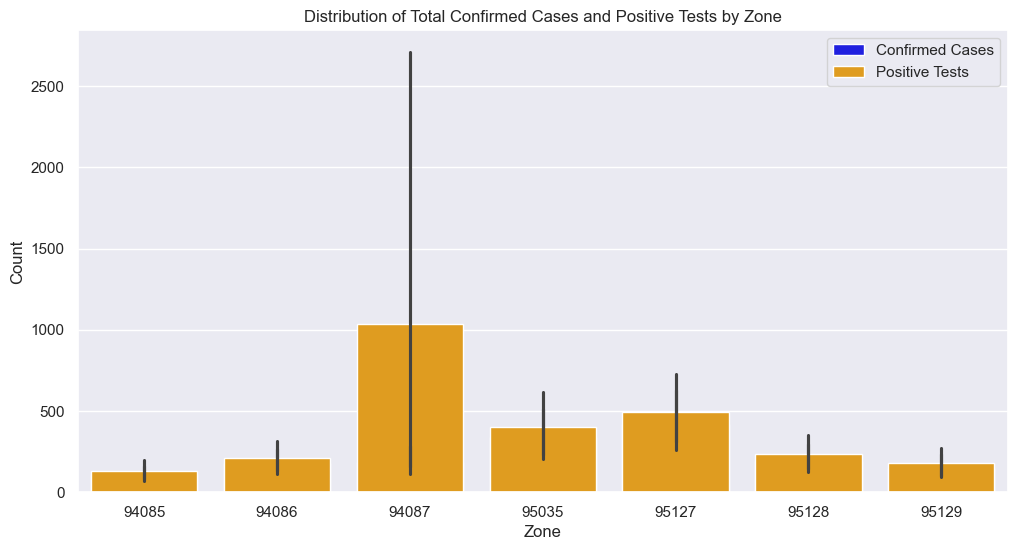

In [7]:
plt.figure(figsize=(12, 6))

sns.barplot(x='zcta', y='case count', data=df, color='blue', label='Confirmed Cases')
sns.barplot(x='zcta', y='positive tests', data=df, color='orange', label='Positive Tests')

plt.xlabel('Zone')
plt.ylabel('Count')
plt.title('Distribution of Total Confirmed Cases and Positive Tests by Zone')
plt.legend()
plt.show()


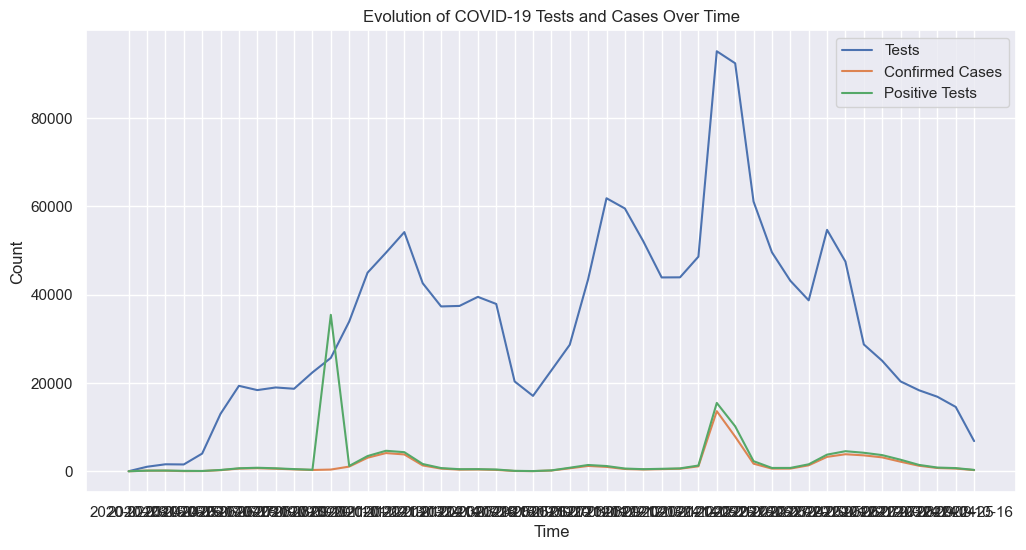

In [8]:
# Group by 'Start date' and sum the values
df_time = df.groupby('Start date')[['test count', 'case count', 'positive tests']].sum()

plt.figure(figsize=(12, 6))

plt.plot(df_time.index, df_time['test count'], label='Tests')
plt.plot(df_time.index, df_time['case count'], label='Confirmed Cases')
plt.plot(df_time.index, df_time['positive tests'], label='Positive Tests')

plt.xlabel('Time')
plt.ylabel('Count')
plt.title('Evolution of COVID-19 Tests and Cases Over Time')
plt.legend()
plt.show()

